# IY011 Contrastive Learning Model Training (Part 3)

In [ ]:
import os
import subprocess
import glob
import tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import time
# plotting 
import matplotlib.pyplot as plt
from visualisation.plots import plot_mRNA_dist, plot_mRNA_trajectory
# ml
import torch, itertools
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from models.ssl_transformer import SSL_Transformer
from training.eval import evaluate_model
from training.train import train_model 

# data handling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load SSL data prep pipeline from modularised code
from utils.data_loader import ssl_data_prep
# we use InfoNCE loss for contrastive learning (use this package: https://github.com/RElbers/info-nce-pytorch)
from info_nce import InfoNCE
import wandb

%load_ext autoreload
%autoreload 2  

In [2]:
DATA_ROOT = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY011/data")
RESULTS_PATH = DATA_ROOT / "IY011_simulation_parameters_sobol.csv" #  this csv file stores all the simulation parameters used
df_params = pd.read_csv(RESULTS_PATH) 
# TRAJ_PATH = [DATA_ROOT / f"mRNA_trajectories_mu{row['mu_target']:.3f}_cv{row['cv_target']:.3f}_tac{row['t_ac_target']:.3f}.csv" for idx, row in df_params.iterrows()] # the trajectories 
TRAJ_PATH = [DATA_ROOT / df_params['trajectory_filename'].values[i] for i in range(len(df_params))]
TRAJ_NPZ_PATH = [traj_file.with_suffix('.npz') for traj_file in TRAJ_PATH]

In [3]:
# === Dataloader hyperparams & data prep ===
batch_size = 256 # !!! Batch size affects the performance of contrastive learning significantly - higher better!!!
num_groups_train=200  
num_groups_val=num_groups_train // 10
num_groups_test=num_groups_train // 10
num_traj=2
train_loader, val_loader, test_loader, scaler = ssl_data_prep(
    TRAJ_NPZ_PATH,
    batch_size=batch_size,
    num_groups_train=num_groups_train,
    num_groups_val=num_groups_val,
    num_groups_test=num_groups_test,
    log_scale=True, # whether to log-scale the data
)
# === Dataloader hyperparams & data prep ===

Files split: 655 Train, 164 Val, 205 Test
Generating 200 training pairs...


Building positive groups: 100%|██████████| 200/200 [00:00<00:00, 23908.02it/s]
Building negative groups: 0it [00:00, ?it/s]


Generating validation/test pairs...


Building positive groups: 100%|██████████| 20/20 [00:00<00:00, 21172.66it/s]
Building negative groups: 0it [00:00, ?it/s]
Building positive groups: 100%|██████████| 20/20 [00:00<00:00, 19328.59it/s]
Building negative groups: 0it [00:00, ?it/s]

Fitting scaler on Log-Transformed training data...


In [4]:
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)

torch.Size([200, 200, 1]) torch.Size([200, 200, 1]) torch.Size([200])


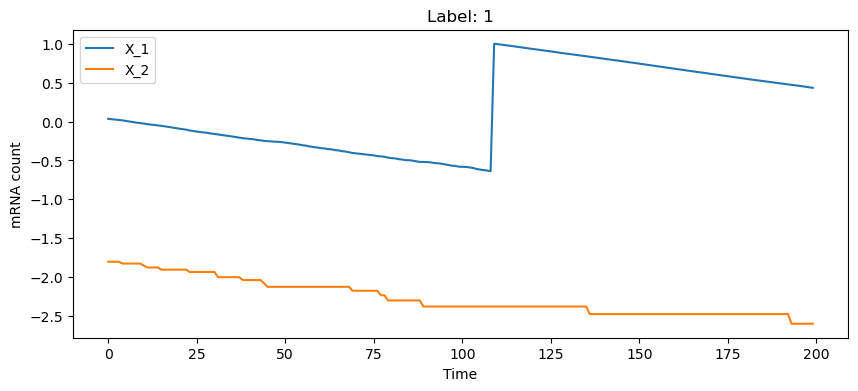

In [5]:
# plot the first pair in the batch
plt.figure(figsize=(10,4))
plt.plot(X1_b[0,:,0].numpy(), label='X_1')
plt.plot(X2_b[0,:,0].numpy(), label='X_2')
plt.title(f"Label: {y_b[0].item()}")
plt.xlabel("Time")
plt.ylabel("mRNA count")
plt.legend()
plt.show()

In [6]:
# === Model hyperparams ===
input_size = 1
num_classes = 2
d_model=64
nhead=4
num_layers=2
dropout=0.001
use_conv1d=False 

model = SSL_Transformer(
    input_size=input_size,   
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    dropout=dropout,
    use_conv1d=use_conv1d,
)
# === Model hyperparams ===

# === Training hyperparams ===
epochs = 100
patience = 10
lr = 1e-3
optimizer = optim.Adam(model.parameters(), lr=lr)

### schedulers ### 
# 1. simple scheduler choice
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5) 

# 2. cosine scheduler with warmup, most commonly used for transformer
total_steps = epochs * len(train_loader)
warmup_steps = int(0.1 * total_steps)   # 10% warmup (good default)
#  (from huggingface)
from transformers import get_cosine_schedule_with_warmup
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
) 

loss_fn = InfoNCE(negative_mode='unpaired') # use InfoNCE loss for contrastive learning
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
grad_clip = 1.0
save_path = None
verbose = True

model.to(device)
# === Training hyperparams ===

/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SSL_Transformer(
  (backbone): TransformerClassifier(
    (input_proj): Linear(in_features=1, out_features=64, bias=True)
    (pe): PositionalEncoding()
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.001, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, bias=True)
          (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.001, inplace=False)
          (dropout2): Dropout(p=0.001, inplace=False)
        )
      )
    )
    (dropout): Dropout(p=0.001, inplace=False)
    (head): Linear(in_features=64, out_features=2, bias=True)
 

In [7]:
# === wandb config (required for tracking within train_model) ===
wandb_config = {
    "entity": "grignard-reagent",
    "project": "IY011-SSL",
    "name": f"SSL_batch_size_{batch_size}_num_group_train_{num_groups_train}", # change this to what you want
    "dataset": DATA_ROOT.name,
    "batch_size": batch_size,
    "input_size": input_size,
    "d_model": d_model,
    "nhead": nhead,
    "num_layers": num_layers,
    "num_classes": num_classes,
    "dropout": dropout,
    "use_conv1d": use_conv1d,
    "epochs": epochs,
    "patience": patience,
    "lr": lr,
    "optimizer": type(optimizer).__name__,
    "scheduler": type(scheduler).__name__,
    "loss_fn": type(loss_fn).__name__,
    "model": type(model).__name__,
    "batch_size": train_loader.batch_size,
    "num_traj_per_group": num_traj,
    "num_groups_train": num_groups_train,
    "num_groups_val": num_groups_val,
    "num_groups_test": num_groups_test,
}
# === wandb config === 

In [8]:
from training.train import train_ssl_model
history = train_ssl_model(
    model,
    train_loader,
    val_loader,
    epochs=epochs,
    patience=patience,
    lr=lr,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_fn=loss_fn,
    device=device,
    grad_clip=grad_clip,
    save_path=save_path,
    verbose=verbose,
    # wandb_logging=True, # this enables wandb logging within train_model
    # wandb_config=wandb_config, # pass the config dictionary
)

Starting SSL training...
[SSL] Epoch [1/100] | train_loss 5.5224 | train_acc 0.0150 | val_loss 3.1678 | val_acc 0.1000
No improvement (1/10).
[SSL] Epoch [2/100] | train_loss 5.4200 | train_acc 0.0150 | val_loss 3.0991 | val_acc 0.1000
No improvement (2/10).
[SSL] Epoch [3/100] | train_loss 5.4957 | train_acc 0.0250 | val_loss 2.9908 | val_acc 0.1000
No improvement (3/10).
[SSL] Epoch [4/100] | train_loss 5.4374 | train_acc 0.0300 | val_loss 2.8908 | val_acc 0.1000
No improvement (4/10).
[SSL] Epoch [5/100] | train_loss 5.2692 | train_acc 0.0250 | val_loss 2.8493 | val_acc 0.1000
No improvement (5/10).
[SSL] Epoch [6/100] | train_loss 5.2174 | train_acc 0.0300 | val_loss 2.8595 | val_acc 0.1000
No improvement (6/10).
[SSL] Epoch [7/100] | train_loss 5.2116 | train_acc 0.0250 | val_loss 2.8734 | val_acc 0.1000
No improvement (7/10).
[SSL] Epoch [8/100] | train_loss 5.2363 | train_acc 0.0150 | val_loss 2.8766 | val_acc 0.1000
No improvement (8/10).
[SSL] Epoch [9/100] | train_loss 5.2036

In [9]:
# save the trained model
model_path = "IY011_SSL_transformer_model.pth"
torch.save(model.state_dict(), model_path)

In [10]:
# model_path = "IY011_SSL_transformer_model.pth"
# model.load_state_dict(torch.load(model_path))

## Test the model on test_loader

This measures the contrastive accuracy, i.e., how well the model performs on the pretext task using data from the same distribution as the training data.

In [9]:
import torch
import torch.nn.functional as F
import numpy as np

def calculate_contrastive_accuracy(z1, z2):
    """
    Checks if z1[i] is closest to z2[i] in the batch.
    """
    # Normalize
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    
    # Similarity Matrix (Batch x Batch)
    scores = torch.matmul(z1, z2.T)
    
    # Targets are the diagonal (0, 1, 2...)
    targets = torch.arange(z1.size(0)).to(z1.device)
    
    # Top-1 Accuracy
    preds = torch.argmax(scores, dim=1)
    correct = (preds == targets).float().sum()
    
    return correct.item(), z1.size(0)

def evaluate_on_test_loader(model, test_loader, device='cpu'):
    model.eval()
    total_correct = 0
    total_samples = 0
    
    print(f"Running InfoNCE Evaluation on test_loader...")
    
    with torch.no_grad():
        for batch in test_loader:
            # Unpack (x1, x2, y) - we ignore y
            x1, x2, _ = batch
            x1 = x1.to(device)
            x2 = x2.to(device)
            
            # Forward pass
            z1, z2 = model(x1, x2)
            
            # Calc acc
            correct, batch_size = calculate_contrastive_accuracy(z1, z2)
            total_correct += correct
            total_samples += batch_size
            
    acc = total_correct / total_samples
    print(f"------------------------------------------------")
    print(f"📊 InfoNCE Contrastive Accuracy: {acc:.2%}")
    print(f"   (Random chance is 1/{test_loader.batch_size} = {1/test_loader.batch_size:.1%})")
    print(f"------------------------------------------------")
    return acc

In [10]:
# 1. Setup
device = next(model.parameters()).device

# 2. Run InfoNCE Evaluation (Pretext Task)
# Measures embedding quality on same-distribution data
contrastive_acc = evaluate_on_test_loader(model, test_loader, device=device)

Running InfoNCE Evaluation on test_loader...
------------------------------------------------
📊 InfoNCE Contrastive Accuracy: 15.00%
   (Random chance is 1/256 = 0.4%)
------------------------------------------------


## Test the model on unseen_datasets (downstream task)

This is different from the pretext task. Here, we evaluate how well the learned embeddings transfer to new, unseen classes using a few-shot learning approach with a KNN classifier.

In [11]:
from simulation.mean_cv_t_ac import find_tilda_parameters
from simulation.julia_simulate_telegraph_model import simulate_telegraph_model

def generate_unseen_classes(n_classes=5, n_trajs_per_class=20, seq_len=3000):
    """
    Generates N new 'mystery' datasets with random parameters.
    Returns a list of dictionaries, each representing a unique biological condition.
    """
    print(f"Generating {n_classes} unseen classes...")
    unseen_data = []
    
    # Randomly sample parameters (Mu, CV, Tac)
    # We pick ranges similar to your training data to ensure they are valid biological possibilities
    mus = np.random.uniform(10, 1000, n_classes)
    cvs = np.random.uniform(0.5, 2.0, n_classes)
    tacs = np.random.uniform(5, 50, n_classes)
    
    time_points = np.arange(0, seq_len, 1.0)

    for i in range(n_classes):
        try:
            # 1. Solve for physical parameters
            rho, d, sigma_b, sigma_u = find_tilda_parameters(mus[i], tacs[i], cvs[i])
            
            # 2. Simulate
            params = [{"sigma_b": sigma_b, "sigma_u": sigma_u, "rho": rho, "d": d, "label": 0}]
            df = simulate_telegraph_model(params, time_points, n_trajs_per_class)
            
            # 3. Extract clean array (N_trajs, Time)
            # Assuming format: columns t_0...t_T, rows are trajectories
            # Adjust filtering based on your exact df structure
            trajs = df.drop(columns=['label'], errors='ignore').values
            
            unseen_data.append({
                "class_id": f"Mystery_Class_{i}",
                "parameters": {"mu": mus[i], "cv": cvs[i], "tac": tacs[i]},
                "trajectories": trajs
            })
            print(f"  Generated Class {i}: Mu={mus[i]:.1f}, CV={cvs[i]:.2f}")
            
        except Exception as e:
            print(f"  Skipped a class due to solver error: {e}")
            
    return unseen_data

In [12]:
from sklearn.neighbors import KNeighborsClassifier

# --- A. Setup Reference Library ---
def build_robust_library(data_list, model, scaler, crop_len=200, n_shots=5, device='cpu'):
    model.eval()
    backbone = model.backbone
    
    ref_features = []
    ref_labels = []
    
    print(f"Building Few-Shot Library ({n_shots}-shot)...")
    
    with torch.no_grad():
        for data in data_list:
            class_id = data['class_id']
            # Take first N trajectories
            raw_trajs = data['trajectories'][:n_shots] 
            
            # 1. Sanitize & Log
            raw_trajs = np.nan_to_num(raw_trajs, nan=0.0)
            raw_trajs = np.maximum(raw_trajs, 0.0)
            log_trajs = np.log1p(raw_trajs)
            
            # 2. Scale
            N, T = log_trajs.shape
            scaled = scaler.transform(log_trajs.reshape(-1, 1)).reshape(N, T)
            scaled = np.nan_to_num(scaled, nan=0.0)
            
            # 3. Crop & Tensorize
            crops = []
            for t in scaled:
                if len(t) >= crop_len:
                    crops.append(t[:crop_len])
                else:
                    pad = crop_len - len(t)
                    crops.append(np.pad(t, (0, pad), mode='edge'))
            
            tensor = torch.tensor(np.array(crops), dtype=torch.float32).unsqueeze(-1).to(device)
            
            # 4. Embed
            emb = backbone.encode(tensor).mean(dim=1).cpu().numpy()
            
            for v in emb:
                ref_features.append(v)
                ref_labels.append(class_id)
                
    # Fit KNN
    X_ref = np.stack(ref_features) # Force 2D
    if X_ref.ndim == 1: X_ref = X_ref.reshape(-1, 1)
    
    knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
    knn.fit(X_ref, np.array(ref_labels))
    return knn

# --- B. Test Loop ---
def evaluate_few_shot(unseen_data, model, scaler, knn, crop_len=200, n_shots=5, device='cpu'):
    model.eval()
    backbone = model.backbone
    correct = 0
    total = 0
    
    print(f"Running Few-Shot Classification on Unseen Data...")
    
    with torch.no_grad():
        for data in unseen_data:
            true_class = data['class_id']
            # Test on REMAINDER of data (queries)
            queries = data['trajectories'][n_shots:] 
            
            for q in queries:
                # Preprocess Query
                q = np.nan_to_num(q, nan=0.0)
                q = np.maximum(q, 0.0)
                q_log = np.log1p(q)
                
                # Random Crop for robustness
                if len(q_log) > crop_len:
                    start = np.random.randint(0, len(q_log) - crop_len)
                    q_crop = q_log[start : start+crop_len]
                else:
                    q_crop = np.pad(q_log, (0, crop_len - len(q_log)), mode='edge')
                
                # Scale
                q_scaled = scaler.transform(q_crop.reshape(-1, 1)).reshape(crop_len)
                q_scaled = np.nan_to_num(q_scaled, nan=0.0)
                
                # Tensor
                q_tensor = torch.tensor(q_scaled, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
                
                # Embed
                emb = backbone.encode(q_tensor).mean(dim=1).cpu().numpy()
                if emb.ndim == 1: emb = emb.reshape(1, -1)
                
                # Predict
                pred = knn.predict(emb)[0]
                
                if pred == true_class:
                    correct += 1
                total += 1
                
    acc = correct / total
    print(f"------------------------------------------------")
    print(f"🧬 Downstream Few-Shot Accuracy: {acc:.2%}")
    print(f"------------------------------------------------")
    return acc

In [13]:
# 3. Generate Unseen Data
unseen_datasets = generate_unseen_classes(n_classes=5, n_trajs_per_class=20)

# 4. Build KNN Library using the Robust Function
knn_engine = build_robust_library(unseen_datasets, model, scaler, device=device)

# 5. Run Few-Shot Evaluation (Downstream Task)
# Measures transfer learning capability
few_shot_acc = evaluate_few_shot(unseen_datasets, model, scaler, knn_engine, device=device)

Generating 5 unseen classes...


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Initializing Julia environment...


  Activating project at `~/stochastic_simulations/julia`


Using 12 threads for Julia simulation..


: 

## Visualise Embeddings with PCA

In [ ]:
# Visualise embeddings with PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 


Generating embeddings for t-SNE...
Running t-SNE on 5 samples...


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


: 